## Feature Engineering

For feature engineering, we tried to clean the data and turn some of the columns into values that would make more sense for the models. We removed the `Id` column because it is just a row number and should not really help with predicting `SalePrice`. For `Alley`, instead of keeping the original column with a lot of missing values, we made a new column called `Has_Alley`. This just says whether the house has alley access or not.

We also filled in missing values depending on what the column was supposed to mean. For example, we used the median for `LotFrontage` because it is a numeric column and the median is a safe value to use when there are outliers. For `MasVnrArea`, we filled missing values with 0 because if there is no masonry veneer, then the area should basically be 0. For columns about things like basement, garage, fireplace, pool, fence, and other extra features, we filled the missing values with `None`, since missing usually means the house does not have that thing.

Some categorical columns had a clear order, so we changed them into numbers. For example, quality ratings like `Ex`, `Gd`, `TA`, `Fa`, and `Po` were changed into scores. We did this because these labels are not random categories; they go from better to worse. We also made a `HasBsmt` column to show if the house has a basement. Other columns like `LandSlope`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`, `CentralAir`, `Electrical`, `Functional`, `GarageFinish`, and `Fence` were also mapped to numbers because their categories had some kind of ranking or meaning.

For the columns where there was no obvious order, we used one-hot encoding with `pd.get_dummies()`. This was used for columns like zoning, neighborhood, house style, roof type, exterior type, foundation, heating, garage type, sale type, and sale condition. We also dropped `Utilities` because almost all of the values were the same, so it probably would not help the model much.

At the end, we created a few new columns from the existing ones. `TotalBathrooms` adds together the full and half bathrooms, including the basement bathrooms. `Age` tells how old the house was when it was sold, and `RemodAge` tells how many years it had been since the house was remodeled. We also made `TotalSF`, which combines basement area, first floor area, second floor area, wood deck area, and open porch area. The idea was that total space might be more useful than looking at all of those area columns separately.

In [67]:
url = 'https://raw.githubusercontent.com/dana-fatemeh/Final-ML-Project/main/Data/train.csv'

import pandas as pd

data = pd.read_csv(url)

print(data.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [68]:
import pandas as pd
import numpy as np


def feature_engineer(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    if "Id" in data.columns:
        data = data.drop(columns=["Id"])

    data["Has_Alley"] = data["Alley"].notna().astype(int)
    data = data.drop(columns=["Alley"])

    # In this dataset, NA usually means the house does not have that feature.
    none_cols = [
        "MasVnrType",
        "BsmtQual",
        "BsmtCond",
        "BsmtExposure",
        "BsmtFinType1",
        "BsmtFinType2",
        "FireplaceQu",
        "PoolQC",
        "Fence",
        "MiscFeature",
        "GarageType",
        "GarageFinish",
        "GarageQual",
        "GarageCond",
    ]

    for col in none_cols:
        if col in data.columns:
            data[col] = data[col].fillna("None")

    zero_cols = [
        "GarageYrBlt",
        "GarageCars",
        "GarageArea",
        "BsmtFinSF1",
        "BsmtFinSF2",
        "BsmtUnfSF",
        "TotalBsmtSF",
        "BsmtFullBath",
        "BsmtHalfBath",
        "MasVnrArea",
    ]

    for col in zero_cols:
        if col in data.columns:
            data[col] = data[col].fillna(0)

    data["LotFrontage"] = data["LotFrontage"].fillna(data["LotFrontage"].median())
    data["Electrical"] = data["Electrical"].fillna(data["Electrical"].mode()[0])

    lotshape_map = {"Reg": 0, "IR1": 1, "IR2": 2, "IR3": 3}
    data["LotShape"] = data["LotShape"].map(lotshape_map)

    qual_rate = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}
    ord_cols = [
        "ExterQual",
        "ExterCond",
        "BsmtQual",
        "BsmtCond",
        "HeatingQC",
        "KitchenQual",
        "FireplaceQu",
        "GarageQual",
        "GarageCond",
        "PoolQC",
    ]

    data["HasBsmt"] = (data["BsmtQual"] != "None").astype(int)

    for col in ord_cols:
        data[col + "_ord"] = data[col].map(qual_rate)
        data = data.drop(columns=[col])

    data["LandSlope"] = data["LandSlope"].map({"Gtl": 1, "Mod": 2, "Sev": 3})
    data["BsmtExposure"] = data["BsmtExposure"].map({"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "None": 0})
    data["BsmtFinType1"] = data["BsmtFinType1"].map(
        {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "None": 0}
    )
    data["BsmtFinType2"] = data["BsmtFinType2"].map(
        {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "None": 0}
    )
    data["CentralAir"] = data["CentralAir"].map({"Y": 1, "N": 0})
    data["Functional"] = data["Functional"].map(
        {"Typ": 7, "Min1": 6, "Min2": 5, "Mod": 4, "Maj1": 3, "Maj2": 2, "Sev": 1, "Sal": 0}
    )
    data["GarageFinish"] = data["GarageFinish"].map({"Fin": 3, "RFn": 2, "Unf": 1, "None": 0})
    data["Fence"] = data["Fence"].map({"GdPrv": 4, "MnPrv": 3, "GdWo": 2, "MnWw": 1, "None": 0})

    if "Utilities" in data.columns:
        data = data.drop(columns=["Utilities"])

    # MSSubClass is numeric in the CSV, but it is really a dwelling category.
    data["MSSubClass"] = data["MSSubClass"].astype(str)

    data["TotalBathrooms"] = (
        data["FullBath"] + 0.5 * data["HalfBath"] + data["BsmtFullBath"] + 0.5 * data["BsmtHalfBath"]
    )

    data["YearRemodAdd"] = data["YearRemodAdd"].astype(int)
    data["YearBuilt"] = data["YearBuilt"].astype(int)
    data["YrSold"] = data["YrSold"].astype(int)
    data["Age"] = data["YrSold"] - data["YearBuilt"]
    data["RemodAge"] = data["YrSold"] - data["YearRemodAdd"]

    data["TotalSF"] = data["TotalBsmtSF"] + data["1stFlrSF"] + data["2ndFlrSF"]
    data["TotalPorchSF"] = (
        data["OpenPorchSF"]
        + data["EnclosedPorch"]
        + data["3SsnPorch"]
        + data["ScreenPorch"]
        + data["WoodDeckSF"]
    )

    data["QualGrLivArea"] = data["OverallQual"] * data["GrLivArea"]
    data["QualTotalSF"] = data["OverallQual"] * data["TotalSF"]
    data["TotalQuality"] = data["OverallQual"] + data["OverallCond"]

    data["HasGarage"] = (data["GarageArea"] > 0).astype(int)
    data["HasFireplace"] = (data["Fireplaces"] > 0).astype(int)
    data["HasPool"] = (data["PoolArea"] > 0).astype(int)

    data["LogLotArea"] = np.log1p(data["LotArea"])
    data["LogGrLivArea"] = np.log1p(data["GrLivArea"])
    data["LogTotalSF"] = np.log1p(data["TotalSF"])

    categorical_cols = data.select_dtypes(include=["object"]).columns
    data = pd.get_dummies(data, columns=categorical_cols, dtype=int)

    return data

In [69]:
# url = 'https://raw.githubusercontent.com/dana-fatemeh/Final-ML-Project/main/Data/train.csv'

# import pandas as pd

# data = pd.read_csv(url)
data = feature_engineer(data)
data.head()

,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtExposure,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65.0,8450,0,1,7,5,2003,2003,196.0,1,...,0,0,0,1,0,0,0,0,1,0
1,80.0,9600,0,1,6,8,1976,1976,0.0,4,...,0,0,0,1,0,0,0,0,1,0
2,68.0,11250,1,1,7,5,2001,2002,162.0,2,...,0,0,0,1,0,0,0,0,1,0
3,60.0,9550,1,1,7,5,1915,1970,0.0,1,...,0,0,0,1,1,0,0,0,0,0
4,84.0,14260,1,1,8,5,2000,2000,350.0,3,...,0,0,0,1,0,0,0,0,1,0


In [70]:
print(len(data))

1460


In [71]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 253 entries, LotFrontage to SaleCondition_Partial
dtypes: float64(7), int64(246)
memory usage: 2.8 MB


In [72]:
data.describe()


,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtExposure,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,69.863699,10516.828082,0.408219,1.062329,6.099315,5.575342,1971.267808,1984.865753,103.117123,1.630137,...,0.003425,0.083562,0.002055,0.867808,0.069178,0.002740,0.008219,0.013699,0.820548,0.085616
std,22.027677,9981.264932,0.582296,0.276232,1.382997,1.112799,30.202904,20.645407,180.731373,1.067391,...,0.058440,0.276824,0.045299,0.338815,0.253844,0.052289,0.090317,0.116277,0.383862,0.279893
min,21.000000,1300.000000,0.000000,1.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,7553.500000,0.000000,1.000000,5.000000,5.000000,1954.000000,1967.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,69.000000,9478.500000,0.000000,1.000000,6.000000,5.000000,1973.000000,1994.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,79.000000,11601.500000,1.000000,1.000000,7.000000,6.000000,2000.000000,2004.000000,164.250000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,313.000000,215245.000000,3.000000,3.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,4.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [73]:
data.dtypes

,0
LotFrontage,float64
LotArea,int64
LotShape,int64
LandSlope,int64
OverallQual,int64
...,...
SaleCondition_AdjLand,int64
SaleCondition_Alloca,int64
SaleCondition_Family,int64
SaleCondition_Normal,int64


## Correlation
Let's see what is the correlation between the features

In [74]:
# Separate into numerical features that don't need preprocessing, and categorical features that need to be transformed
num_feat = data.select_dtypes(include=['int64','float64']).columns
# print(num_feat[30:50])
# cat_feat = data.select_dtypes(include=['object','bool']).columns
print(len(num_feat))

253


In [75]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline
import seaborn as sns
import plotly.express as px

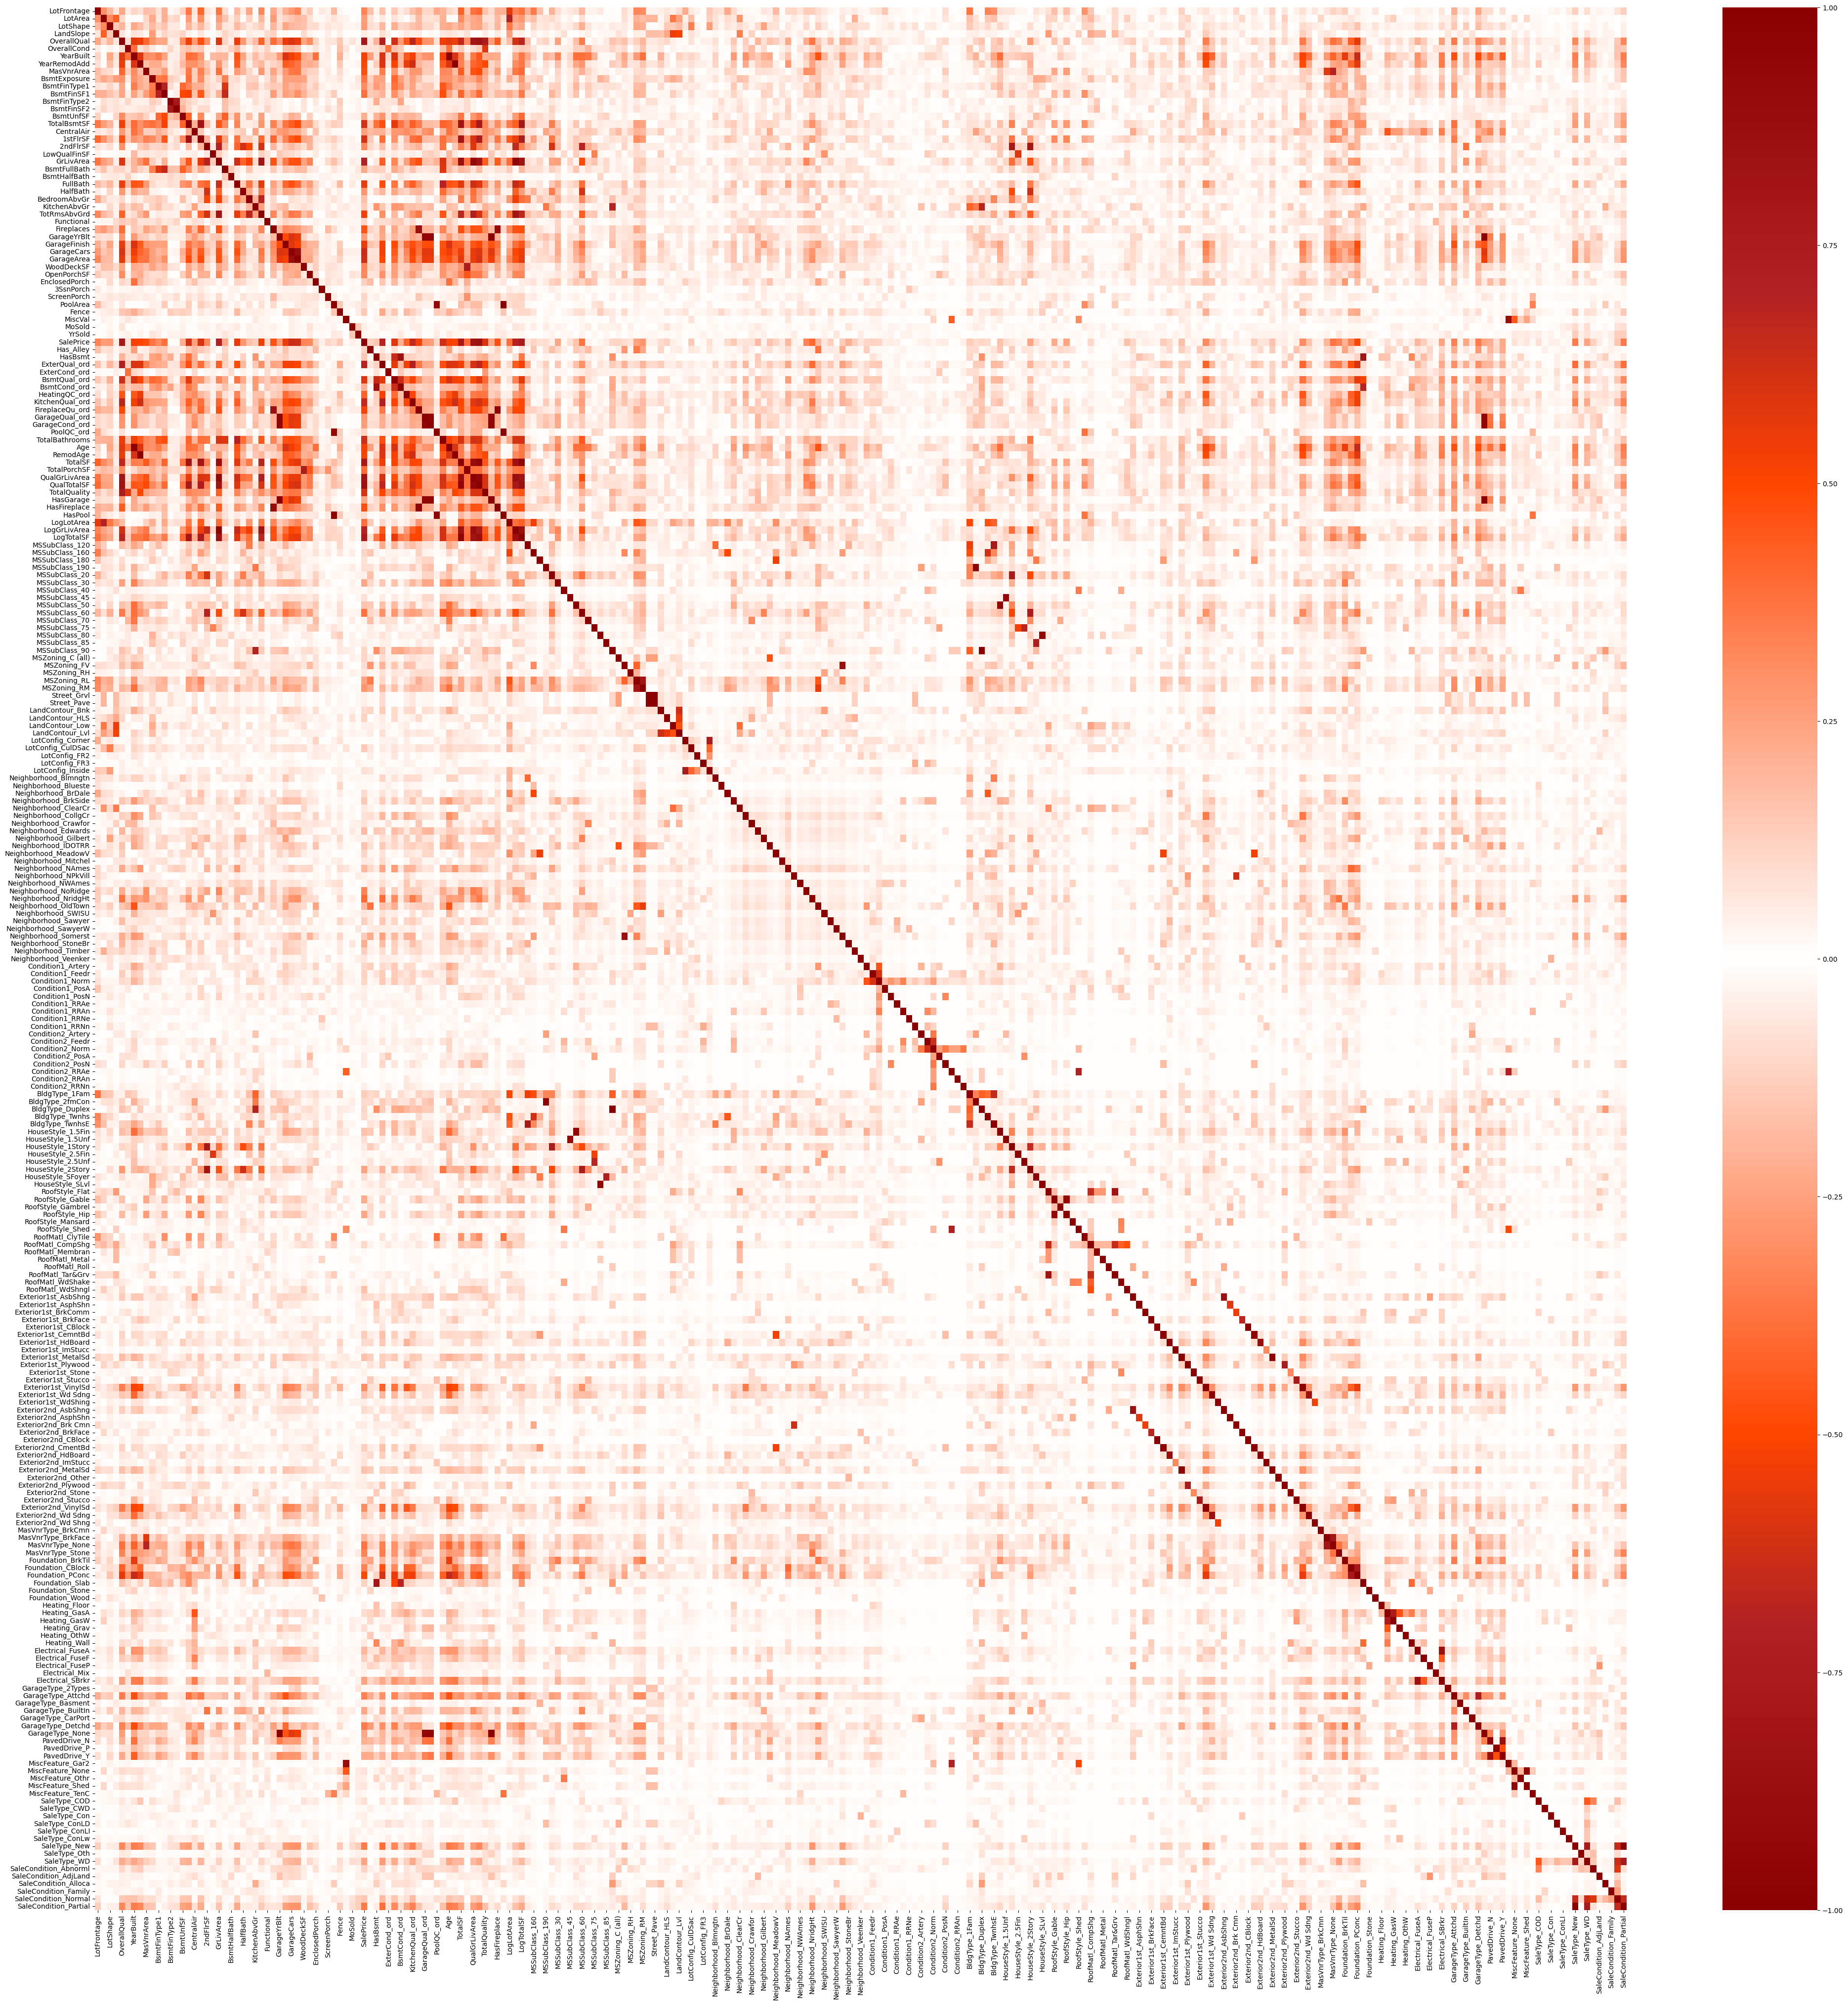

In [76]:
plt.figure(figsize=(50,50))
cor = data[num_feat].corr()

# Custom edits to colormap to show 0 "no correlation" as white, and both correlation extremes as equal colors
colors = ["darkred", "firebrick", "orangered", "white", "orangered", "firebrick", "darkred"]
nodes = [0.0, 0.15, 0.25, 0.5, 0.75, 0.85, 1.0]
double_prawn = mcolors.LinearSegmentedColormap.from_list("double_prawn", list(zip(nodes, colors)))
fit_colors = mcolors.TwoSlopeNorm(vmin=-1.0, vcenter=0, vmax=1.0)

sns.heatmap(cor,cmap=double_prawn, norm=fit_colors)
plt.show()

## Cross-Validation ^^ 

For cross-validation, we prepared the data so each model could be tested on multiple validation folds instead of only one train/test split. We first separated `SalePrice` as the target variable `y`, then used the rest of the columns as `X`.

Because these models are tree-based models, especially decision trees and random forests, we do not need `StandardScaler`. Scaling does not usually improve a random forest because the model splits on feature order, not distance. We only impute missing values inside each fold so the validation fold does not leak information into the training fold.

We use 4-fold cross-validation. This means the training data is split into four parts, and each part gets used once as validation data while the other three parts are used for training. The final table reports the mean and standard deviation across the four folds.

In [77]:
# Axis Prep
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split, KFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import time
from tabulate import tabulate
import numpy as np

# Set 'SalePrice' as y
# We use log1p because SalePrice is right-skewed. Later, use expm1 to convert predictions back to dollars.
y = np.log1p(data["SalePrice"]) if "SalePrice" in data.columns else None
X = data.drop(columns=["SalePrice"]) if "SalePrice" in data.columns else data.copy()

if y is not None:
    # Keep one untouched holdout set for the final model check.
    X_total_raw, X_test_hierarchical_raw, y_total, y_test_hierarchical = train_test_split(
        X, y.values, test_size=0.2, random_state=1234
    )

    # Random forests do not need scaling. We only impute missing values.
    imputer = SimpleImputer(strategy="most_frequent")
    X_total = imputer.fit_transform(X_total_raw)
    X_test_hierarchical = imputer.transform(X_test_hierarchical_raw)

    # This small split is only used for the later prediction/residual visualizations.
    X_train, X_test, y_train, y_test = train_test_split(
        X_total, y_total, test_size=0.2, random_state=1234
    )

In [78]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold


def model_eva_sklearn(XTrain, XTest, yTrain, yTest, model):
    yTrain_pred = model.predict(XTrain)
    yTest_pred = model.predict(XTest)

    MAE_train = mean_absolute_error(yTrain, yTrain_pred)
    MSE_train = mean_squared_error(yTrain, yTrain_pred)
    RMSE_train = np.sqrt(MSE_train)
    R2_train = r2_score(yTrain, yTrain_pred)

    MAE_test = mean_absolute_error(yTest, yTest_pred)
    MSE_test = mean_squared_error(yTest, yTest_pred)
    RMSE_test = np.sqrt(MSE_test)
    R2_test = r2_score(yTest, yTest_pred)

    return MAE_train, MSE_train, RMSE_train, R2_train, MAE_test, MSE_test, RMSE_test, R2_test


def cross_validate_model(model, X_data, y_data, n_splits=4, random_state=1234):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_data), start=1):
        fold_model = clone(model)
        X_fold_train_raw = X_data.iloc[train_idx]
        X_fold_val_raw = X_data.iloc[val_idx]
        y_fold_train, y_fold_val = y_data[train_idx], y_data[val_idx]

        imputer = SimpleImputer(strategy="most_frequent")
        X_fold_train = imputer.fit_transform(X_fold_train_raw)
        X_fold_val = imputer.transform(X_fold_val_raw)

        fold_model.fit(X_fold_train, y_fold_train)
        metrics = model_eva_sklearn(
            X_fold_train, X_fold_val, y_fold_train, y_fold_val, fold_model
        )

        fold_results.append({
            "Fold": fold,
            "Training MAE": metrics[0],
            "Training MSE": metrics[1],
            "Training RMSE": metrics[2],
            "Training R^2": metrics[3],
            "Validation MAE": metrics[4],
            "Validation MSE": metrics[5],
            "Validation RMSE": metrics[6],
            "Validation R^2": metrics[7],
        })

    return pd.DataFrame(fold_results)


def summarize_cv_results(model_name, cv_results):
    metric_cols = [col for col in cv_results.columns if col != "Fold"]
    summary = {"Model": model_name}

    for col in metric_cols:
        summary[f"{col} Mean"] = cv_results[col].mean()
        summary[f"{col} Std"] = cv_results[col].std()

    return summary


def print_cv_results(model_name, cv_results):
    print(f"{model_name} 4-Fold Cross-Validation Results")
    print(tabulate(cv_results, headers="keys", tablefmt="grid", showindex=False))

## Models

For the modeling part, we tested three tree-based regression models with 4-fold cross-validation: an unrestricted decision tree, a regularized decision tree, and a tuned random forest. Cross-validation splits the training data into four different train/validation folds, so each model is evaluated on multiple validation sets instead of only one split.

The unrestricted decision tree is included to show overfitting. It gets almost perfect training scores because it memorizes the training rows, but its validation scores are much worse. The regularized decision tree uses limits such as `max_depth`, `min_samples_split`, and `min_samples_leaf` to reduce overfitting.

The best model is the tuned random forest with 700 trees and `max_features="sqrt"`. On the local 4-fold cross-validation run, it reached about 0.0879 mean validation MAE, 0.1301 mean validation RMSE, and 0.8916 mean validation R^2 on the log-transformed sale price. After comparing the mean validation metrics across the four folds, we keep the tuned random forest as the final model and evaluate it one more time on the untouched holdout set.

In [79]:
from sklearn.tree import DecisionTreeRegressor
from tabulate import tabulate

# decision tree model with no hyperparameters to show overfitting
dt_model_overfit = DecisionTreeRegressor(
    random_state=1234
)

cv_dt_overfit = cross_validate_model(dt_model_overfit, X_total_raw, y_total, n_splits=4)
print_cv_results("DecisionTree Overfit", cv_dt_overfit)

results = []
results.append(summarize_cv_results("DecisionTree Overfit", cv_dt_overfit))

DecisionTree Overfit 4-Fold Cross-Validation Results
+--------+----------------+----------------+-----------------+----------------+------------------+------------------+-------------------+------------------+
|   Fold |   Training MAE |   Training MSE |   Training RMSE |   Training R^2 |   Validation MAE |   Validation MSE |   Validation RMSE |   Validation R^2 |
+========+================+================+=================+================+==================+==================+===================+==================+
|      1 |              0 |              0 |               0 |              1 |         0.138534 |        0.0375434 |          0.193761 |         0.76396  |
+--------+----------------+----------------+-----------------+----------------+------------------+------------------+-------------------+------------------+
|      2 |              0 |              0 |               0 |              1 |         0.144199 |        0.0403365 |          0.20084  |         0.748226 |
+----

In [80]:
from sklearn.tree import DecisionTreeRegressor

# decision tree model with hyperparameters to prevent overfitting
dt_model = DecisionTreeRegressor(
    max_depth=20,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=1234
)

cv_dt = cross_validate_model(dt_model, X_total_raw, y_total, n_splits=4)
print_cv_results("DecisionTree", cv_dt)

results.append(summarize_cv_results("DecisionTree", cv_dt))

DecisionTree 4-Fold Cross-Validation Results
+--------+----------------+----------------+-----------------+----------------+------------------+------------------+-------------------+------------------+
|   Fold |   Training MAE |   Training MSE |   Training RMSE |   Training R^2 |   Validation MAE |   Validation MSE |   Validation RMSE |   Validation R^2 |
+========+================+================+=================+================+==================+==================+===================+==================+
|      1 |      0.0867223 |      0.0156925 |        0.12527  |       0.89922  |         0.12437  |        0.0265896 |          0.163063 |         0.832828 |
+--------+----------------+----------------+-----------------+----------------+------------------+------------------+-------------------+------------------+
|      2 |      0.083592  |      0.0141892 |        0.119119 |       0.908636 |         0.135517 |        0.0353935 |          0.188132 |         0.77908  |
+--------+---

In [81]:
from sklearn.ensemble import RandomForestRegressor

# tuned random forest model
rf_model = RandomForestRegressor(
    n_estimators=700,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=1234,
    n_jobs=1,
)

cv_rf = cross_validate_model(rf_model, X_total_raw, y_total, n_splits=4)
print_cv_results("RandomForest Tuned", cv_rf)

results.append(summarize_cv_results("RandomForest Tuned", cv_rf))

cv_summary = pd.DataFrame(results)
print("4-Fold Cross-Validation Summary")
print(tabulate(cv_summary, headers="keys", tablefmt="grid", showindex=False))

# Fit once on the visualization split so the later plots still work.
rf_model.fit(X_train, y_train)

RandomForest Tuned 4-Fold Cross-Validation Results
+--------+----------------+----------------+-----------------+----------------+------------------+------------------+-------------------+------------------+
|   Fold |   Training MAE |   Training MSE |   Training RMSE |   Training R^2 |   Validation MAE |   Validation MSE |   Validation RMSE |   Validation R^2 |
+========+================+================+=================+================+==================+==================+===================+==================+
|      1 |      0.0333002 |     0.00249591 |       0.0499591 |       0.983971 |        0.0872247 |        0.0155685 |          0.124774 |         0.902119 |
+--------+----------------+----------------+-----------------+----------------+------------------+------------------+-------------------+------------------+
|      2 |      0.0321789 |     0.00229664 |       0.0479232 |       0.985212 |        0.0900321 |        0.0182426 |          0.135065 |         0.886133 |
+------

RandomForestRegressor(max_features='sqrt', n_estimators=700, n_jobs=1,
                      random_state=1234)

After choosing our best model, we tested it on data it had not seen before.

In [82]:
# train final model on all training data from the outer split
final_rf_model = RandomForestRegressor(
    n_estimators=700,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=1234,
    n_jobs=1,
)

final_rf_model.fit(X_total, y_total)

# final evaluation on untouched holdout set
final_pred = final_rf_model.predict(X_test_hierarchical)

final_mae = mean_absolute_error(y_test_hierarchical, final_pred)
final_mse = mean_squared_error(y_test_hierarchical, final_pred)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test_hierarchical, final_pred)

print("Final MAE:", final_mae)
print("Final MSE:", final_mse)
print("Final RMSE:", final_rmse)
print("Final R^2:", final_r2)

Final MAE: 0.09317272429525703
Final MSE: 0.023381881809886054
Final RMSE: 0.15291135278286586
Final R^2: 0.8628335330726763


## Visualization 

For the visualization part, we used graphs to understand the data better and also to check how our final model was doing. First, we plotted the distribution of `SalePrice` with a histogram and KDE line. This helped us see how house prices were spread out and showed that most houses were in the lower and middle price range, while fewer houses had very high prices.

We also made scatter plots between `SalePrice` and the numeric features. The goal was to see which features had a strong relationship with price. For example, `TotalSF` had a positive relationship with `SalePrice`, which makes sense because bigger houses usually sell for more. `Age` had more of a negative relationship, meaning older houses often had lower prices. We also included a feature like `Foundation_Wood` to show an example where there was not really a clear relationship with `SalePrice`.

After building the random forest model, we made a predicted vs actual price plot. This was useful because if the model was doing well, the points should be close to the red diagonal line. We also plotted the residuals, which are the prediction errors. That helped us see how far off the model usually was and whether the errors were mostly centered around zero.

Finally, we plotted the top 20 random forest feature importances. This showed which features the model relied on the most when making predictions. We also compared actual and predicted prices against important features like `TotalSF` and `OverallQual`, so we could visually check if the model was following the same general trends as the real data. Overall, the visualizations helped us explain both the dataset patterns and the performance of the random forest model.

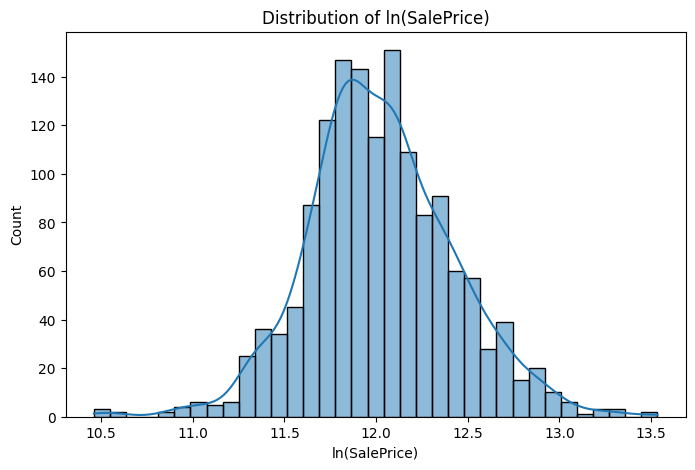

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(np.log(data["SalePrice"]), kde=True)
plt.title("Distribution of ln(SalePrice)")
plt.xlabel("ln(SalePrice)")
plt.ylabel("Count")
plt.show()


In [57]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Select only numeric columns
# numeric_data = data.select_dtypes(include=["int64", "float64"])

# # Find features most correlated with SalePrice
# numeric_data["SalesPrice"] = np.log(numeric_data["SalePrice"])
# corr_with_price = numeric_data.corr()["SalesPrice"].sort_values(ascending=False)

# # Remove SalesPrice itself
# top_features = corr_with_price.drop("SalesPrice").index


# n_cols = 8
# n_rows = int(np.ceil(len(top_features) / n_cols))

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
# axes = axes.flatten()

# for i, feature in enumerate(top_features):
#     sns.scatterplot(
#         data=data,
#         x=feature,
#         y="SalesPrice",
#         ax=axes[i],
#         alpha=0.6
#     )

#     corr_value = data[[feature, "SalePrice"]].corr().iloc[0, 1]

#     axes[i].set_title(f"{feature} vs SalePrice\nCorrelation: {corr_value:.2f}")
#     axes[i].set_xlabel(feature)
#     axes[i].set_ylabel("SalePrice")

# # Remove empty plots if there are any
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()


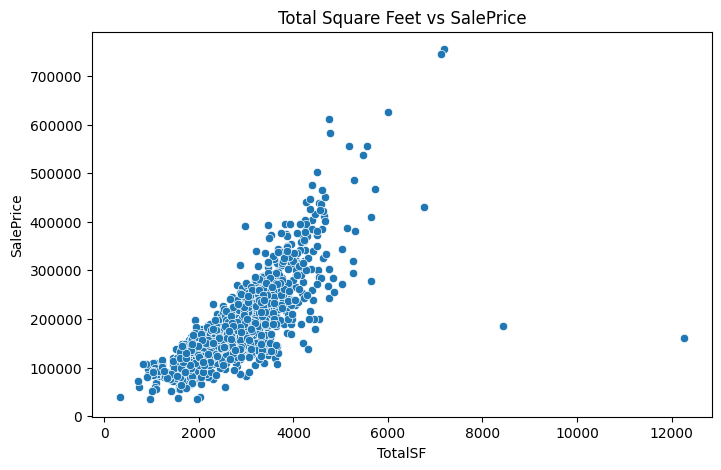

In [58]:
#positively correlated feature with SalePrice is TotalSF
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="TotalSF", y="SalePrice")
plt.title("Total Square Feet vs SalePrice")
plt.xlabel("TotalSF")
plt.ylabel("SalePrice")
plt.show()


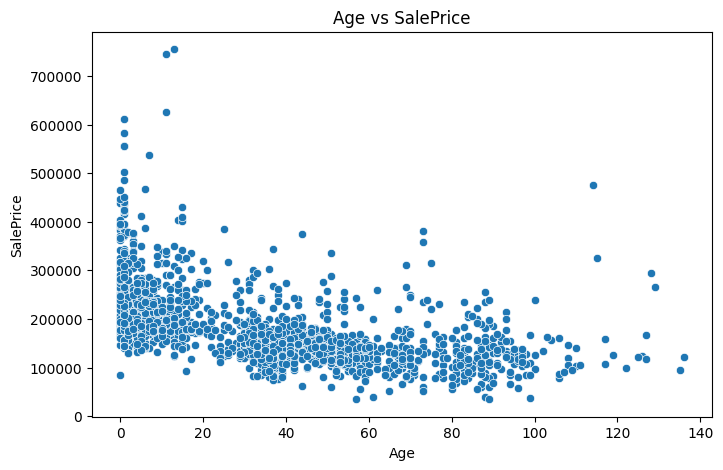

In [59]:
#negatively correlated feature with SalePrice is Age
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="Age", y="SalePrice")
plt.title("Age vs SalePrice")
plt.xlabel("Age")
plt.ylabel("SalePrice")
plt.show()


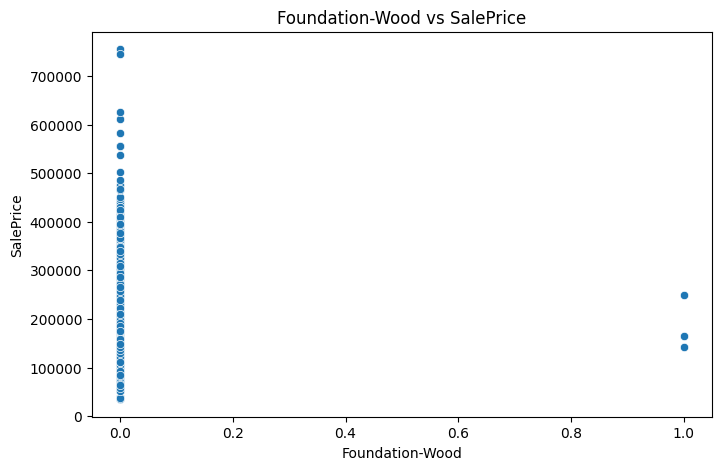

In [60]:
#no correlated feature with SalePrice is Age
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="Foundation_Wood", y="SalePrice")
plt.title("Foundation-Wood vs SalePrice")
plt.xlabel("Foundation-Wood")
plt.ylabel("SalePrice")
plt.show()


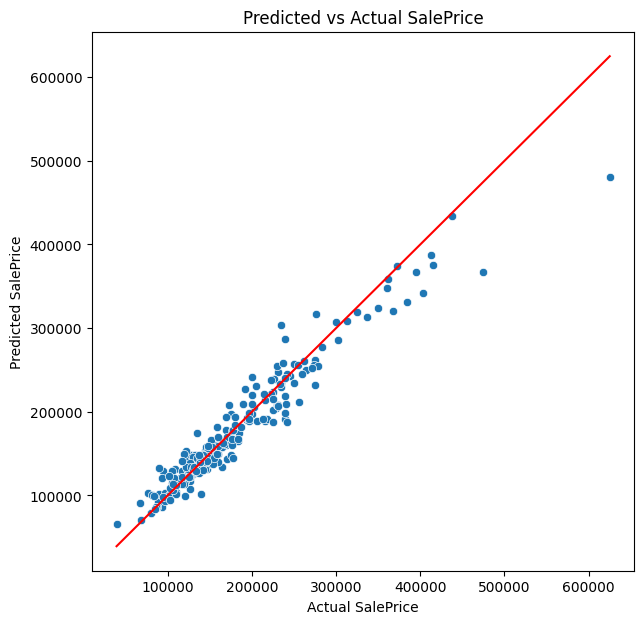

In [61]:
y_pred_log = rf_model.predict(X_test)

y_test_price = np.expm1(y_test)
y_pred_price = np.expm1(y_pred_log)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test_price, y=y_pred_price)

min_price = min(y_test_price.min(), y_pred_price.min())
max_price = max(y_test_price.max(), y_pred_price.max())
plt.plot([min_price, max_price], [min_price, max_price], color="red")

plt.title("Predicted vs Actual SalePrice")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.show()



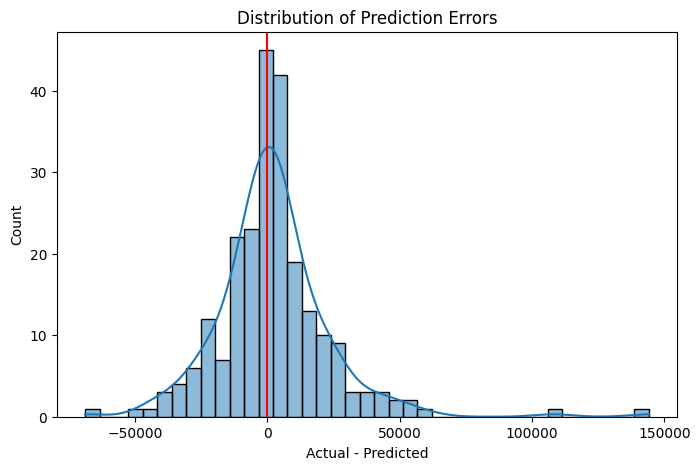

In [62]:
residuals = y_test_price - y_pred_price

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.axvline(0, color="red")
plt.title("Distribution of Prediction Errors")
plt.xlabel("Actual - Predicted")
plt.ylabel("Count")
plt.show()


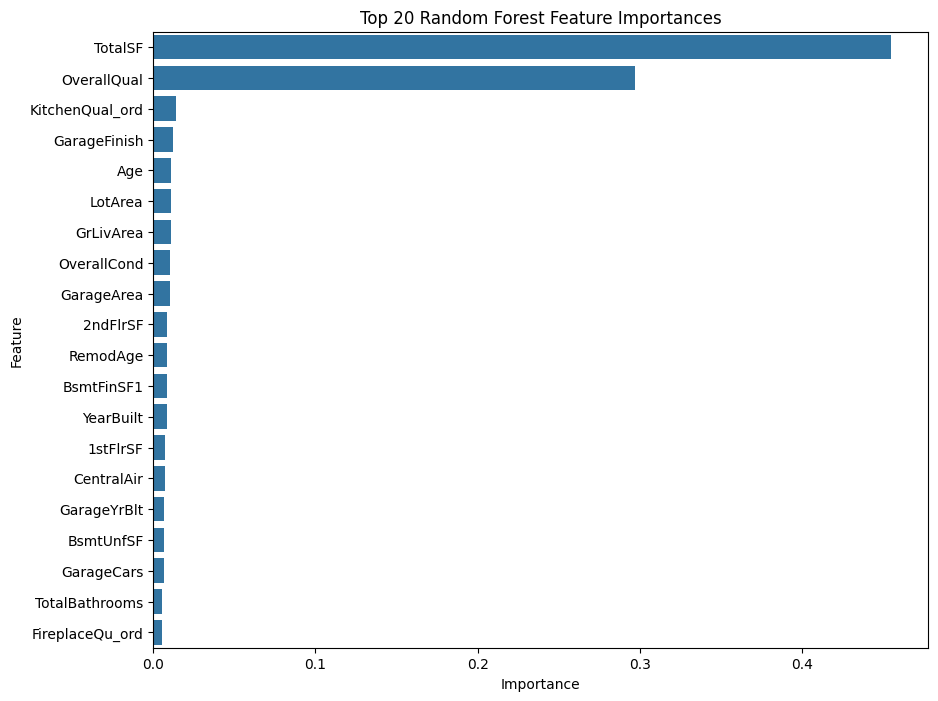

In [63]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


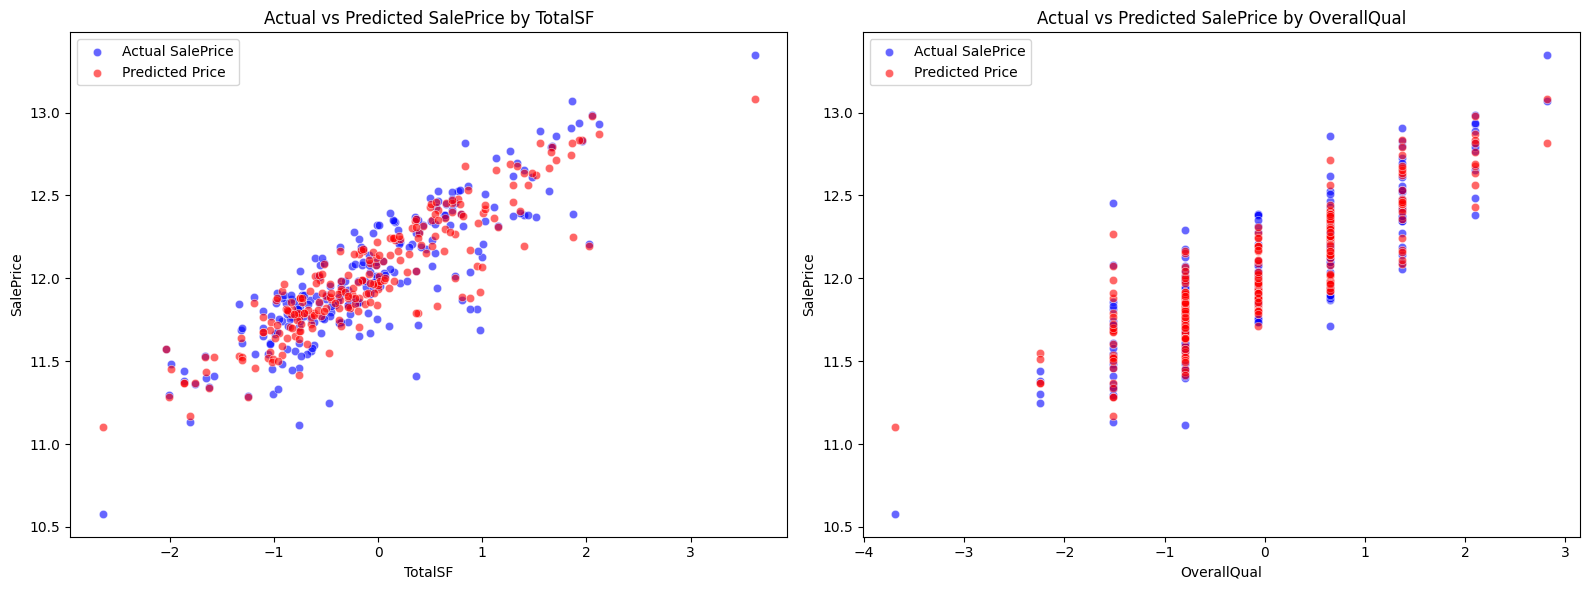

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Predict prices for your validation/test split
y_pred = rf_model.predict(X_test)

# Put actual and predicted values together with the features
plot_data = X_test.copy()

# If X_test is a numpy array because of imputer/scaler, rebuild it as a DataFrame
if not isinstance(plot_data, pd.DataFrame):
    plot_data = pd.DataFrame(X_test, columns=X.columns)

plot_data["Actual_SalePrice"] = y_test
plot_data["Predicted_SalePrice"] = y_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TotalSF plot
sns.scatterplot(
    data=plot_data,
    x="TotalSF",
    y="Actual_SalePrice",
    color="blue",
    label="Actual SalePrice",
    alpha=0.6,
    ax=axes[0]
)

sns.scatterplot(
    data=plot_data,
    x="TotalSF",
    y="Predicted_SalePrice",
    color="red",
    label="Predicted Price",
    alpha=0.6,
    ax=axes[0]
)

axes[0].set_title("Actual vs Predicted SalePrice by TotalSF")
axes[0].set_xlabel("TotalSF")
axes[0].set_ylabel("SalePrice")
axes[0].legend()

# OverallQual plot
sns.scatterplot(
    data=plot_data,
    x="OverallQual",
    y="Actual_SalePrice",
    color="blue",
    label="Actual SalePrice",
    alpha=0.6,
    ax=axes[1]
)

sns.scatterplot(
    data=plot_data,
    x="OverallQual",
    y="Predicted_SalePrice",
    color="red",
    label="Predicted Price",
    alpha=0.6,
    ax=axes[1]
)

axes[1].set_title("Actual vs Predicted SalePrice by OverallQual")
axes[1].set_xlabel("OverallQual")
axes[1].set_ylabel("SalePrice")
axes[1].legend()

plt.tight_layout()
plt.show()


In [65]:
# numeric_data = data.select_dtypes(include=["int64", "float64"])

# # plt.figure(figsize=(14, 10))
# # corr = numeric_data.corr()
# # sns.heatmap(corr, cmap="coolwarm", center=0)
# # plt.title("Correlation Heatmap")
# # plt.show()

# corr_with_price = numeric_data.corr()["SalePrice"].sort_values(ascending=False)

# plt.figure(figsize=(10, 40))
# corr_with_price.plot(kind="barh")
# plt.title("Top Features Correlated with SalePrice")
# plt.xlabel("Correlation")
# plt.gca().invert_yaxis()
# plt.show()


## Kaggle Submisssion

In this part, we prepared the Kaggle submission file. We used our final random forest model to predict `SalePrice` for the test dataset, then saved the results with the house `Id` and predicted `SalePrice` in a CSV file that can be submitted to Kaggle.

In [ ]:
from pathlib import Path

import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer


TEST_PATH = "Data/test.csv"
SUBMISSION_PATH = "Data/submission.csv"


test_raw = pd.read_csv(TEST_PATH)
test_ids = test_raw["Id"]

train_data = data.copy()
test_data = feature_engineer(test_raw)

y = np.log1p(train_data["SalePrice"])

X = train_data.drop(columns=["SalePrice"])
test_data = test_data.reindex(columns=X.columns, fill_value=0)

imputer = SimpleImputer(strategy="most_frequent")
X_imputed = imputer.fit_transform(X)
test_imputed = imputer.transform(test_data)

rf_model = RandomForestRegressor(
    n_estimators=700,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=1234,
    n_jobs=1,
)
rf_model.fit(X_imputed, y)

log_sale_price_predictions = rf_model.predict(test_imputed)
sale_price_predictions = np.expm1(log_sale_price_predictions)

submission = pd.DataFrame(
    {
        "Id": test_ids,
        "SalePrice": sale_price_predictions,
    }
)
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Saved {SUBMISSION_PATH} with {len(submission)} rows.")


# from google.colab import files

# files.download("submission.csv")